### **Figure 3: _Loss of keratin expression diminishes EVL epiboly movements_ Notebook**

This notebook provides tools and data to recreate the figure 3 from Naik et al 2026. 
It has been modified code from the original [repo](https://github.com/Suyash-Naik/PaperPythonScripting) to allow for all orginal source data retrival from the repository and plotting using standarized versions of the code to plot the figures. 

**Author**: Suyash Naik

In [1]:
#Import block
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.BinnedPlotter import BinnedIntensityPlotter
import matplotlib.patches as mpatches
from src.Figureplot import setup_figure
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from glob import glob
import re 
import os

Figureplot.py run on  20260811


### **Figure 7C**: _Plot of epiboly speed with keratin YSL morpholino_

Plot of EVL epiboly movement speed as a function of time (hpf) during epiboly in Tg(actb2: Utrophin-mcherry, krt18:Krt18GFP) embryos injected with 2ng control MO (green) (N = 4, n = 8 embryos ) or 1 ng keratin 4 plus 1 ng keratin 8 MO (blue) (N = 4, n = 7 embryos) into the YSL at sphere stage (3.3 hpf). Error bars as ribbon SD of mean.

In [4]:
yslspeed=pd.read_csv("data/Fig7/7C/YSLK4K8MOSpeedData.csv")
controlcols=[col for col in yslspeed.columns if "control" in col]
morphantcols=[col for col in yslspeed.columns if "ysl" in col]
controlmean=np.nanmean(yslspeed[controlcols],axis=1)
controlsem=np.nanstd(yslspeed[controlcols],axis=1)
morphantmean=np.nanmean(yslspeed[morphantcols],axis=1)
morphantsem=np.nanstd(yslspeed[morphantcols],axis=1)

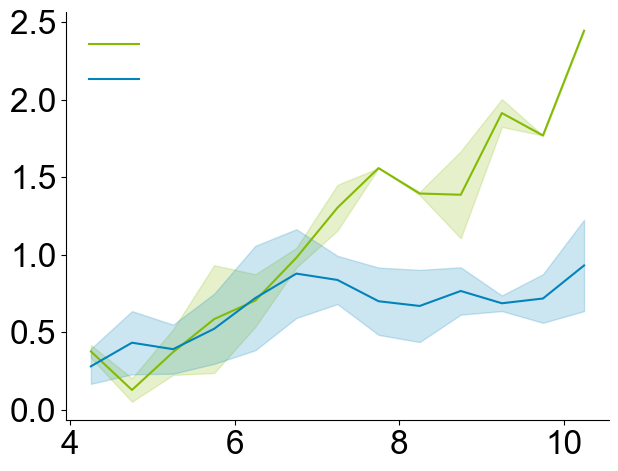

In [8]:
fig,ax=setup_figure()
ax.plot(yslspeed["Time (hpf)"],controlmean,color='#83bb03',label="     ")
ax.fill_between(yslspeed["Time (hpf)"],controlmean-controlsem,controlmean+controlsem,alpha=0.2,color="#83bb03")  
ax.plot(yslspeed["Time (hpf)"],morphantmean,color="#0383bb",label="     ")
ax.fill_between(yslspeed["Time (hpf)"],morphantmean-morphantsem,morphantmean+morphantsem,alpha=0.2,color="#0383bb")  
plt.legend(loc="upper left",frameon=False,fontsize=18)
plt.show()    

### **Figure 7D**: _Actin retrograde flow in morphants_

Plot of retrograde actin flow velocity in the YSL as a function of distance from the EVL-YSL boundary in Tg(actb2: Utrophin-mcherry, krt18:Krt18GFP) embryos at shield stage (6 hpf) injected with 2 ng control MO (green)(N = 3, n = 6 embryos) or 1 ng keratin 4 plus 1 ng keratin 8 MO (blue) (N = 3, n = 6 embryos) into the YSL at sphere stage (3.3 hpf). 

Error bars as ribbon SD of mean.

In [32]:
controldict=pickle.load(open("data/Fig7/7D/Controldict.pkl","rb"))
ysldict=pickle.load(open("data/Fig7/7D/YSLdict.pkl","rb"))
controlflow=pd.read_csv("data/Fig7/7D/Control_Flowprofile.csv")
yslflow=pd.read_csv("data/Fig7/7D/YSL_Mo_Flowprofile.csv")
def plot_magdict(magdict):
    for key in magdict.keys():
        plt.plot(magdict[key][0],label=key)
        plt.fill_between(np.arange(len(magdict[key][0])),magdict[key][0]-magdict[key][1],magdict[key][0]+magdict[key][1],alpha=0.5)
def plot_averagemagdict(magdict,dictname:str):
    mean_magdict={}
    for key in magdict.keys():
        mean_magdict[key]=magdict[key][0]
    df=pd.DataFrame(mean_magdict)
    dfmean=df.mean(axis=1)
    dfstd=df.sem(axis=1)
    if dictname=="    ":
        colorname="#83bb03"
    else:
        colorname="#0383bb"
    plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower
    plt.rcParams['font.size'] = 24
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    plt.gca().spines['right'].set_color('none')
    plt.gca().spines['top'].set_color('none')
    #plt.ylabel("Flow velocity(µm/s)")
    plt.plot(dfmean,color=colorname,label=dictname)
    plt.fill_between(dfmean.index,dfmean-dfstd,dfmean+dfstd,alpha=0.3,color=colorname)
    plt.gca().invert_yaxis()

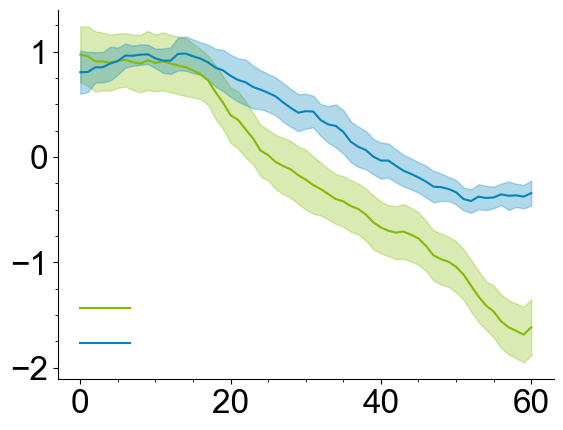

In [36]:
plot_averagemagdict(controldict,  "    ")
plot_averagemagdict(ysldict, "        ")
plt.legend(loc="lower left",frameon=False,fontsize=18)
plt.xticks(np.arange(0,60,5),minor=True)
plt.yticks(np.arange(-2,1.5,0.25),minor=True)
plt.show()

### **Figure 7E**: _Plot of epiboly speed with keratin YSL morpholino_

Box plot of actin intensity in a fixed region of interest (ROI) within the YSL close to the point of micropipette aspiration before (pre Asp) and after (post Asp) aspiration in Tg(actb2: Utrophin-mcherry, krt18:Krt18GFP) embryos at 3.3 hpf injected with 2 ng control MO (green boxes, N = 3 n = 10 embryos) or 1 ng keratin 4 plus 1 ng keratin 8 MO (blue boxes N = 3 n= 13 embryos)  into the YSL at sphere stage (3.3 hpf). N = 4, n = 13 embryos. 

Boxes represent quartiles of the data and error bars the spread (pvalues: ***<0.001, **<00.1 paired t test).

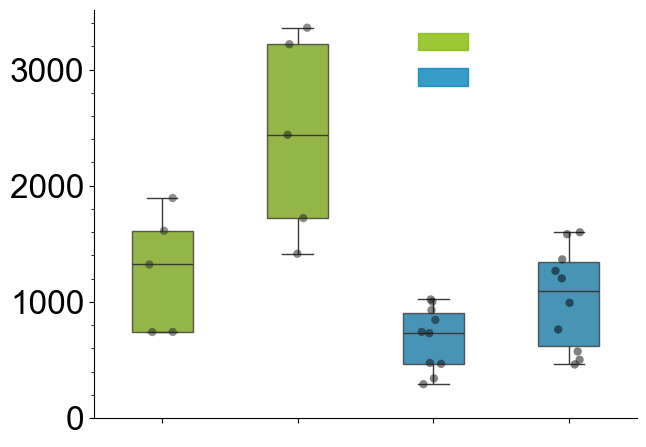

In [13]:
actinaspdf=pd.read_csv("data/Fig7/7E/AspAnalysisBox_2024_Figure5.csv")
fig,ax=setup_figure()
colors = ["#83bb03", "#83bb03", "#0383bb", "#0383bb"]
ax=sns.boxplot(data=actinaspdf, x="Sampleid", y="Intensity", hue="Sampleid", legend="auto", palette=colors, width=0.45, boxprops=dict(alpha=.8))
sns.stripplot(data=actinaspdf, x="Sampleid", y="Intensity", hue="Sampleid",
              palette="dark:black", alpha=0.5, size=6, dodge=False, legend=False, ax=ax)
red_patch = mpatches.Patch(color="#83bb03", label='                  ', alpha=0.8)
blue_patch = mpatches.Patch(color="#0383bb", label='                  ', alpha=0.8)
# Set the x-axis tick labels
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["", "", "", ""])
ax.set_yticks(np.arange(0,3600,200),minor=True)
# Add the legend
ax.legend(handles=[red_patch, blue_patch],frameon=False,fontsize=18)
plt.xlabel(None)
plt.ylabel(None)
outputfolder="Figure/Figure7/7E/"
os.makedirs(outputfolder, exist_ok=True)
plt.savefig(os.path.join(outputfolder,"AspIntensity.png"), dpi=300, bbox_inches='tight',transparent=True)
plt.savefig(os.path.join(outputfolder,"AspIntensity.pdf"), dpi=300, bbox_inches='tight',transparent=True)
plt.savefig(os.path.join(outputfolder,"AspIntensity.svg"), dpi=300, bbox_inches='tight',transparent=True)
plt.show()

### **Figure 7F**: _Actin alignment in ysl flows_

Box plot of actin flow alignment within the YSL at 6 hpf in Tg(actb2: Utrophin-mcherry, krt18:Krt18GFP) embryos injected with 2 ng control MO (green boxes, N = 3 n = 6 emrbyos) or 1 ng keratin 4 plus 1 ng keratin 8 MO (blue boxes, N=3 n =6 embryos)  into the YSL at sphere stage (3.3 hpf). 

Boxes represent quartiles of the data and error bars the spread. (***<0.001, paired t test).

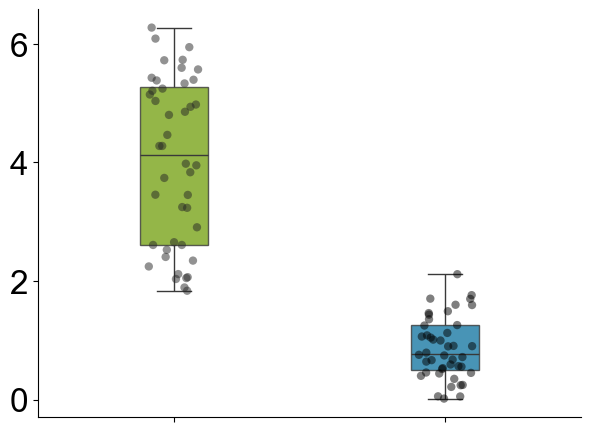

In [2]:
alignmentdata = pd.read_csv("data/Fig7/7F/YSLalignment.csv")
alignmentdata.drop(columns=alignmentdata.columns[:2], inplace=True)

alignmentdata_long = pd.melt(alignmentdata, id_vars=alignmentdata.columns[2:], 
                              var_name='Sample', value_name='Alignment')

fig, ax = setup_figure()
colors = ["#83bb03", "#0383bb"]
sns.boxplot(data=alignmentdata_long, x="Sample", y="Alignment", hue="Sample", palette=colors, width=0.25, boxprops=dict(alpha=.8))
sns.stripplot(data=alignmentdata_long, x="Sample", y="Alignment", hue="Sample",
              palette='dark:black', alpha=0.5, size=6, dodge=False, legend=False, ax=ax)
red_patch = mpatches.Patch(color="#83bb03", label='   ', alpha=0.8)
blue_patch = mpatches.Patch(color="#899aa1", label='       ', alpha=0.8)
#ax.legend(handles=[red_patch, blue_patch], frameon=False, fontsize=18,loc="upper right")
ax.set_xticks([0, 1])
ax.set_xticklabels(["", ""])
plt.xlabel(None)
plt.ylabel(None)
outputfolder="Figure/Figure7/7F/"
os.makedirs(outputfolder, exist_ok=True)
plt.savefig(os.path.join(outputfolder,"YSLalignment.png"), dpi=300, bbox_inches='tight',transparent=True)
plt.savefig(os.path.join(outputfolder,"YSLalignment.pdf"), dpi=300, bbox_inches='tight',transparent=True)
plt.savefig(os.path.join(outputfolder,"YSLalignment.svg"), dpi=300, bbox_inches='tight',transparent=True)
plt.show()

### **FIgure Suplement 7B**: _Utrophin vs keratin flow_

Plot of average flow velocity of keratin (green) and actin (orange) within the YSL in Tg(actb2:Utrophinmcherry, krt18:Krt18GFP) embryos measured using PIV as a function of distance from the EVL-YSL boundary.

In [6]:
# Krt flows correlation
folderkrt2="data/Fig7/Sup/7B"
krtfiles=glob(folderkrt2+"/Krt*/*.txt")
utrfiles=glob(folderkrt2+"/Utr*/*.txt")
def get_krt_data(file):
    datanp=np.loadtxt(file, skiprows=3, delimiter=",")
    x=datanp[:,0]
    y=datanp[:,1]
    u=datanp[:,2]
    v=datanp[:,3]
    magnitude=np.sqrt(u**2+v**2)
    direction=np.arctan2(v,u)
    return x,y,u,v,magnitude,direction
def plot_kspatialaverage(folder,krtfil, utrfile,show=True):
    #fig,ax=plt.subplots()
    x,y,u,v,magnitude,direction=get_krt_data(krtfil)
    x2,y2,u2,v2,magnitude2,direction2=get_krt_data(utrfile)
    colr=0 if "Krt" in krtfil else 1
    # Calculate the average flow profile in y direction
    #plt.figure(figsize=(10, 6))
    mean_magnitude1=np.zeros(len(np.unique(y)))
    mean_magnitudes_std1=np.zeros(len(np.unique(y)))
    mean_magnitude2=np.zeros(len(np.unique(y2)))
    mean_magnitudes_std2=np.zeros(len(np.unique(y2)))

    mean_vmag1=np.zeros(len(np.unique(y)))
    mean_vmag1_std=np.zeros(len(np.unique(y)))
    mean_vmag2=np.zeros(len(np.unique(y2)))
    mean_vmag2_std=np.zeros(len(np.unique(y2)))
    for i,yval in enumerate(np.unique(y)):
        indices=np.where(y==yval)
        mean_magnitude1[i]=np.nanmean(magnitude[indices])
        mean_vmag1[i]=np.nanmean(v[indices])
        mean_magnitudes_std1[i]=np.nanstd(magnitude[indices])
        mean_vmag1_std[i]=np.nanstd(v[indices])
    for i,yval in enumerate(np.unique(y2)):
        indices=np.where(y2==yval)
        mean_magnitude2[i]=np.nanmean(magnitude2[indices])
        mean_vmag2[i]=np.nanmean(v2[indices])
        mean_magnitudes_std2[i]=np.nanstd(magnitude2[indices])
        mean_vmag2_std[i]=np.nanstd(v2[indices])  
    

    #plt.plot(np.unique(y),mean_magnitudes,color="#FF0000",linewidth=2)
    #plt.fill_between(np.unique(y),np.array(mean_magnitudes)-np.array(mean_magnitudes_std),np.array(mean_magnitudes)+np.array(mean_magnitudes_std),color="#FF0000",alpha=0.5)
    colors=["#83bb03", "#0383bb"]
    plt.figure(figsize=(10, 6))
    plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower
    plt.rcParams['font.size'] = 24  
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    plt.gca().spines['right'].set_color('none')
    plt.gca().spines['top'].set_color('none')
    
    plt.plot(np.unique(y),mean_vmag1,color=colors[0], label="Krt flow")
    plt.fill_between(np.unique(y),mean_vmag1-mean_vmag1_std,mean_vmag1+mean_vmag1_std,color=colors[0],alpha=0.5)
    plt.plot(np.unique(y2),mean_vmag2,color=colors[1],label="Utr flow")
    plt.fill_between(np.unique(y2),mean_vmag2-mean_vmag2_std,mean_vmag2+mean_vmag2_std,color=colors[1],alpha=0.5)
    plt.legend(frameon=False,fontsize=18)
    if show:
        plt.show()
    else:
        plt.close()
    return(mean_vmag1,mean_vmag2)
vmagdict={}
for num,file in tqdm(enumerate(krtfiles)):
    name=os.path.basename(file)[:-4]
    # Calculate the average flow profile in y direction
    vmagdict[name]=plot_kspatialaverage(folderkrt2,file,utrfiles[num],show=False)

9it [00:00, 47.65it/s]


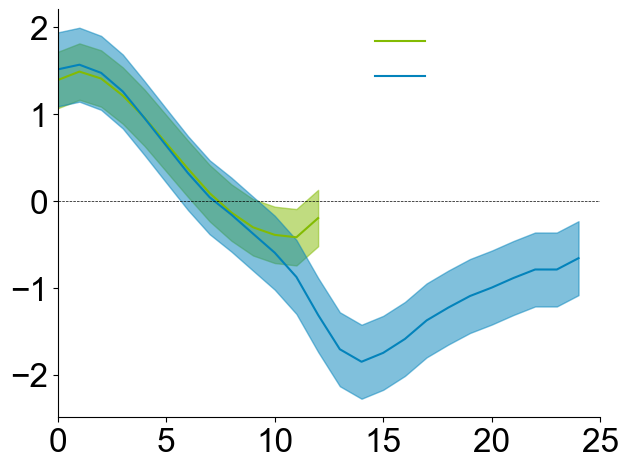

In [9]:
#plot the average flow profile for Krt and Utr
plt.figure(figsize=(7, 5.3)) 
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower
plt.rcParams['font.size'] = 24  
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.gca().spines['right'].set_color('none')
plt.gca().spines['top'].set_color('none')
plt.xlim(0,25)
kvmagavg=[]
uvmagavg=[]
for i,key in enumerate(vmagdict.keys()):
    kvmagavg.append(vmagdict[key][0][:13])
    uvmagavg.append(vmagdict[key][1])
plt.plot(np.nanmean(kvmagavg,axis=0),color="#83bb03", label="                ")
plt.fill_between(np.arange(len(np.nanmean(kvmagavg,axis=0))), np.nanmean(kvmagavg,axis=0)-np.std(kvmagavg)/3, np.nanmean(kvmagavg,axis=0)+np.std(kvmagavg)/3, color="#83bb03", alpha=0.5)
plt.plot(np.nanmean(uvmagavg,axis=0),color="#0383bb", label="                   ")
plt.fill_between(np.arange(len(np.nanmean(uvmagavg,axis=0))), np.nanmean(uvmagavg,axis=0)-np.std(uvmagavg)/3, np.nanmean(uvmagavg,axis=0)+np.std(uvmagavg)/3, color="#0383bb", alpha=0.5)
plt.legend(frameon=False,fontsize=18)
plt.hlines(0,-1,25, color='black', linewidth=0.5, linestyle='--')
if not os.path.exists("H:/PHD_data/Imaging_et_analysis/PaperFigures/Figure5/KrtUtrFlowVel/"):
    os.makedirs("H:/PHD_data/Imaging_et_analysis/PaperFigures/Figure5/KrtUtrFlowVel")
plt.savefig("H:/PHD_data/Imaging_et_analysis/PaperFigures/Figure5/KrtUtrFlowVel/KrtUtrFlowprofile_Thesis.png",dpi=300,transparent=True,bbox_inches='tight')
plt.savefig("H:/PHD_data/Imaging_et_analysis/PaperFigures/Figure5/KrtUtrFlowVel/KrtUtrFlowprofile_Thesis.svg",dpi=300,transparent=True,bbox_inches='tight')
plt.savefig("H:/PHD_data/Imaging_et_analysis/PaperFigures/Figure5/KrtUtrFlowVel/KrtUtrFlowprofile_Thesis.pdf",dpi=300,transparent=True,bbox_inches='tight')
plt.show()

### **Figure Supplement 7D**: _Hydrodynamic lenght in ysl morpahnts_

Box plot of the hydrodynamic length of the YSL actin network measured by UV-laser cutting of the actin cortex in Tg(actb2:Utrophinmcherry, krt18:Krt18GFP) embryos at shield stage (6.5 hpf) injected with control MO (green, N = 4, n = 15 embryos) or 1 ng krt4 plus 1 ng krt8 MO (orange, N = 4, n = 17 embryos) into the YSL at high stage (**<00.1 paired t test). 


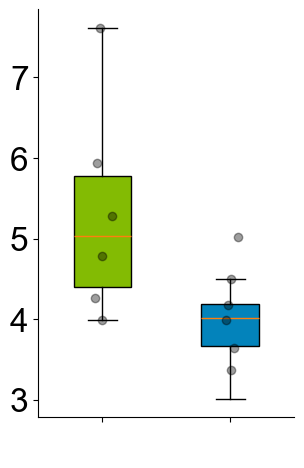

In [ ]:
#hydrodrynamic length
controlHD=pd.read_csv("data/Fig7/Sup/7D/CHydrodynamicLLength.csv")
yslMOHD=pd.read_csv("data/Fig7/Sup/7D/YSLHydrodynamicLLength.csv")
fig,ax=setup_figure(figsize=(3.3, 5.3))
plt.yticks(np.arange(0, 0.5, 0.01), minor=True)
boxplot=plt.boxplot([[1/x for x in controlHD['Control']], [1/x for x in yslMOHD['YSL MO']]],patch_artist=True,widths=0.45,tick_labels=["      ", "   "],showfliers=False)
scatter_x = [1, 2]  # x-coordinates for the scatter points
for i, (control_value, ysl_value) in enumerate(zip(controlHD['Control'], yslMOHD['YSL MO'])):
    jitter1 = 1 + np.random.random()*0.15-0.075
    jitter2 = 2 + np.random.random()*0.15-0.075
    plt.scatter([jitter1, jitter2], [1/control_value, 1/ysl_value], color='black',alpha=0.38, zorder=3)
for iu,bplot in enumerate(boxplot['boxes']):
    bplot.set_facecolor("#83bb03" if iu==0 else "#0383bb")
outputfolder="Figure/Fig7/Sup/7D"
os.makedirs(outputfolder, exist_ok=True)
plt.savefig(f"{outputfolder}/HydrodynamicLength.png",dpi=300,transparent=True,bbox_inches='tight')
plt.savefig(f"{outputfolder}/HydrodynamicLength.svg",dpi=300,transparent=True,bbox_inches='tight')
plt.savefig(f"{outputfolder}/HydrodynamicLength.pdf",dpi=300,transparent=True,bbox_inches='tight')
plt.show()

### **Figure supplement 7E**: _Maximum tissue recoil velocity_

Box plot of initial recoil velocities of the actin cortex after laser ablations in Tg(actb2:Utrophinmcherry, krt18:Krt18GFP) embryos injected with control MO (green, N = 4, n = 15 embryos) or 1 ng krt4 plus 1 ng krt8 MO (orange, N = 4, n = 17 embryos) in the YSL at high stage (**<00.1 paired t test).

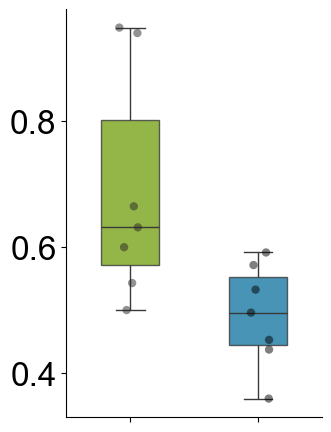

In [28]:


maxvelpd = pd.read_csv("data/Fig7/Sup/7C/MaxVelocityData.csv")

fig, ax = setup_figure(figsize=(3.3, 5.3))
sns.boxplot(data=maxvelpd, x="Label", y="MaxVelocity", hue="Label", palette=["#83bb03", "#0383bb"], width=0.45, boxprops=dict(alpha=.8))
sns.stripplot(data=maxvelpd, x="Label", y="MaxVelocity",
              hue="Label", palette='dark:black', alpha=0.5, size=6, dodge=False, legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["", ""])
plt.xlabel(None)
plt.ylabel(None)
outputfolder="Figure/SupFigure7/7C/"
os.makedirs(outputfolder, exist_ok=True)
plt.savefig(os.path.join(outputfolder,"MaxVelocity.png"), dpi=300, bbox_inches='tight',transparent=True)
plt.savefig(os.path.join(outputfolder,"MaxVelocity.pdf"), dpi=300, bbox_inches='tight',transparent=True)
plt.savefig(os.path.join(outputfolder,"MaxVelocity.svg"), dpi=300, bbox_inches='tight',transparent=True)
plt.show()

In [36]:
YSLintensity = "data/Fig7/Sup/7F"
def read_YSLcututrint(folder:str):
    """Read the YSL cut utrint file and return the data."""
    file_paths = glob(folder + "/*.csv")
    time=[]
    controlInts=[]
    MOInts=[]
    for file in file_paths:
        data = pd.read_csv(file)
        fid= re.findall(r'Pos\d+', file)[0]
        name= f"{fid}"
        #plt.plot(data[" "][:150],data["Mean"][:150],label=file.split("/")[-2],color=["#83bb03"if "Control" in file else "#ff7f0e"][0])
        if "Control" in file:
            controlInts.append(data["Mean"][:150])
        elif "MO" in file:
            MOInts.append(data["Mean"][:150])
    time.append(data[" "][:150]*0.26)#in secs
    controlmean=np.mean(controlInts,axis=0)
    controlstd=np.std(controlInts,axis=0)
    MOmean=np.mean(MOInts,axis=0)
    MOstd=np.std(MOInts,axis=0)
    return(time,controlmean,controlstd,MOmean,MOstd)
time,controlmean,controlstd, momean,mostd=read_YSLcututrint(YSLintensity)

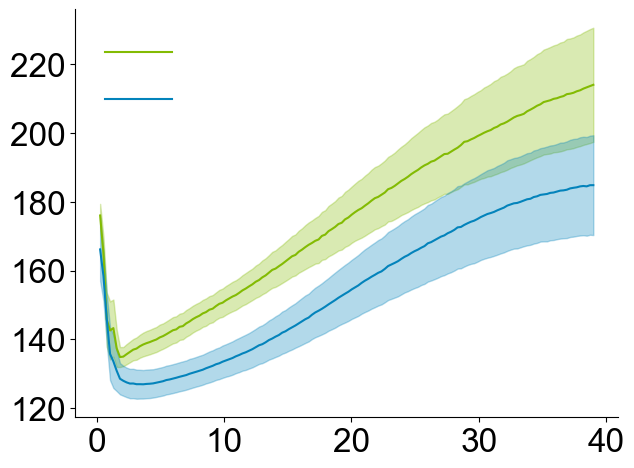

In [38]:
fig,ax = setup_figure()
plt.plot(time[0], controlmean, label='       ', color="#83bb03")
plt.fill_between(time[0], controlmean - controlstd/3, controlmean + controlstd/3, color="#83bb03", alpha=0.3)
plt.plot(time[0], momean, label='             ', color="#0383bb")
plt.fill_between(time[0], momean - mostd/3, momean + mostd/3, color="#0383bb", alpha=0.3)
plt.legend(loc='best', frameon=False, fontsize=24)
plt.show()